# 08 — Hydrological characterization

Everything here follows from one fact: **water runs downhill**, so the bare-earth
DTM encodes where water goes. We use the step-03 corrected DTM (ground, not canopy).
WhiteboxTools does the heavy lifting; each tool reads/writes a GeoTIFF.

**The pipeline, and *why* each step exists:**

1. **Fill depressions.** A DTM has *pits* — cells lower than all neighbours, where
   water entering can't leave. Some are noise; some are real (the talar's old
   *tosqueras* — inactive quarry pits). Flow algorithms deadlock on pits, so we raise
   each pit to its spill level. The **filled − original difference is the
   depression-storage map**: how deep water can pond before overflowing — the
   wetland-ponding signal.
2. **Breach depressions.** An alternative conditioning that *carves a drain* through
   the dam instead of flooding the basin — gentler on real terrain. Used only to make
   the DTM flow-routable for the next steps.
3. **Flow direction (D8).** Each cell points to its single steepest downslope
   neighbour.
4. **Flow accumulation.** Count how many upslope cells drain *through* each cell.
   High accumulation = channels → the drainage network.
5. **Stream extraction.** Threshold the accumulation to get channels.
6. **Stochastic depression analysis.** Perturb the DTM by its error (RMSE) many
   times and count how often each cell ends up in a depression → a **probability of
   ponding** map that honestly propagates the DTM's vertical uncertainty (step 03's
   ~0.3 m).

**Key caveat:** this is a near-flat Río Luján floodplain (a few m of relief), so a
crisp drainage network is unreliable — but **depression/ponding analysis is highly
meaningful** here (tosqueras → wetland).

**Inputs:** `outputs/03_corrected/{talar_dtm_corrected,pastizal_dtm}_0p5m.tif`.
**Outputs:** `outputs/08_hydro/` — filled, storage, breached, flow accumulation,
streams, inundation-probability rasters + figures.

In [1]:
from pathlib import Path
from dataclasses import asdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import plotting_extent

from drone_reserve.hydro import run_hydrology

for parent in [Path.cwd(), *Path.cwd().parents]:
    if (parent / "pyproject.toml").is_file():
        REPO = parent; break
else:
    raise RuntimeError("repo root not found")

CORR = REPO / "outputs" / "03_corrected"
OUT  = REPO / "outputs" / "08_hydro"
FIGS = OUT / "figs"
OUT.mkdir(parents=True, exist_ok=True); FIGS.mkdir(parents=True, exist_ok=True)

DTMS = {"talar":    CORR / "talar_dtm_corrected_0p5m.tif",
        "pastizal": CORR / "pastizal_dtm_0p5m.tif"}

def read1(path):
    with rasterio.open(path) as s:
        a = s.read(1, masked=True); ext = plotting_extent(s)
    return np.where(a.mask, np.nan, a.data), ext
print("OK")

OK


## Run the pipeline for both zones

Each zone runs fill → storage → breach → flow accumulation → streams → stochastic
inundation. The stochastic step repeats the fill 100× under simulated DTM error, so
it takes a minute or two per zone.

In [2]:
results = {}
for zone, dtm in DTMS.items():
    results[zone] = run_hydrology(dtm, OUT, name=zone, stream_threshold_cells=2000,
                                  stoch_rmse=0.3, stoch_range_m=10.0, stoch_iterations=100)
summary = pd.DataFrame([asdict(r) for r in results.values()],
                       index=list(results)).T
pd.set_option("display.float_format", lambda v: f"{v:.2f}")
summary.loc[["zone_area_ha", "storage_volume_m3", "max_depth_m", "inundation_area_ha_p50"]]

,talar,pastizal
zone_area_ha,12.16,13.44
storage_volume_m3,18849.70,20640.10
max_depth_m,9.95,10.05
inundation_area_ha_p50,3.01,3.27


## Depression storage — where water ponds

Filled − original DTM. Capped at 1 m for display so distributed shallow ponding is
visible; we also check whether the (large) maximum is a localized artifact pit.

C:\Users\paco_\AppData\Local\Temp\ipykernel_25560\309893397.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.tight_layout(); fig.savefig(FIGS / "depression_storage.png", dpi=140); fig.show()


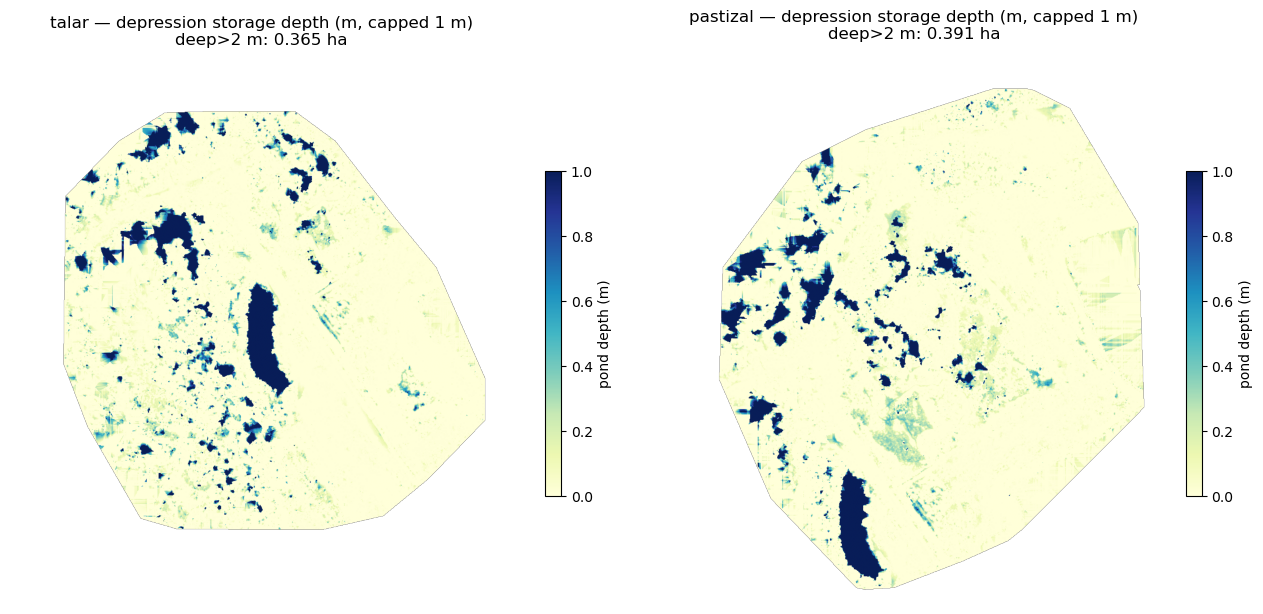

In [3]:
px_ha = 0.5 * 0.5 / 1e4
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, zone in zip(axes, DTMS):
    st, ext = read1(results[zone].storage)
    deep = np.nansum(st > 2.0) * px_ha  # area of 'deep' (>2 m) ponding = likely artifact pits
    im = ax.imshow(st, extent=ext, cmap="YlGnBu", vmin=0, vmax=1.0)
    ax.set_title(f"{zone} — depression storage depth (m, capped 1 m)\n"
                 f"deep>2 m: {deep:.3f} ha"); ax.set_axis_off()
    fig.colorbar(im, ax=ax, shrink=0.6, label="pond depth (m)")
fig.tight_layout(); fig.savefig(FIGS / "depression_storage.png", dpi=140); fig.show()

## Flow accumulation & drainage network

Log-scaled accumulation (bright = many upslope cells = channels), with extracted
streams overlaid. On near-flat terrain treat the network as indicative of drainage
*tendency*, not surveyed channels.

C:\Users\paco_\AppData\Local\Temp\ipykernel_25560\2439765047.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.tight_layout(); fig.savefig(FIGS / "flow_accumulation.png", dpi=140); fig.show()


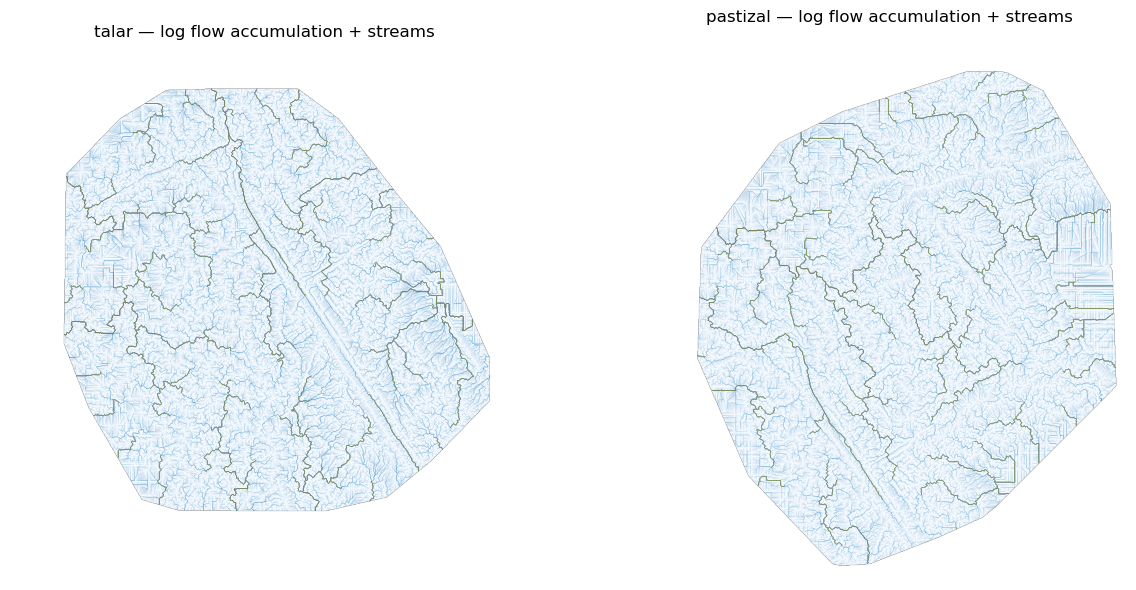

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, zone in zip(axes, DTMS):
    acc, ext = read1(results[zone].flow_accum)
    strm, _ = read1(results[zone].streams)
    ax.imshow(np.log10(np.where(acc > 0, acc, np.nan)), extent=ext, cmap="Blues")
    sm = np.where(np.isfinite(strm) & (strm > 0), 1.0, np.nan)
    ax.imshow(sm, extent=ext, cmap="autumn", vmin=0, vmax=1)
    ax.set_title(f"{zone} — log flow accumulation + streams"); ax.set_axis_off()
fig.tight_layout(); fig.savefig(FIGS / "flow_accumulation.png", dpi=140); fig.show()

## Probable inundation (stochastic depression analysis)

Probability each cell is in a depression given the DTM's ~0.3 m error — a
ponding-probability / probable-inundation map that accounts for terrain uncertainty.

C:\Users\paco_\AppData\Local\Temp\ipykernel_25560\1459420904.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.tight_layout(); fig.savefig(FIGS / "inundation_probability.png", dpi=140); fig.show()


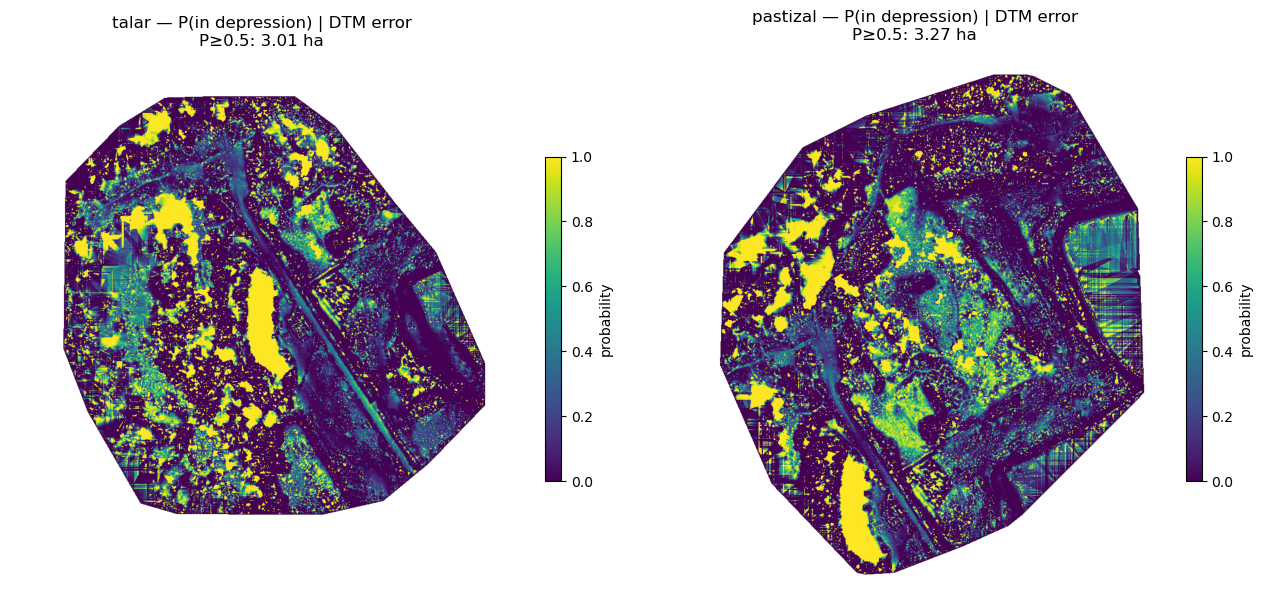

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, zone in zip(axes, DTMS):
    prob, ext = read1(results[zone].inundation_prob)
    im = ax.imshow(prob, extent=ext, cmap="viridis", vmin=0, vmax=1)
    ax.set_title(f"{zone} — P(in depression) | DTM error\n"
                 f"P≥0.5: {results[zone].inundation_area_ha_p50:.2f} ha"); ax.set_axis_off()
    fig.colorbar(im, ax=ax, shrink=0.6, label="probability")
fig.tight_layout(); fig.savefig(FIGS / "inundation_probability.png", dpi=140); fig.show()

In [6]:
pd.DataFrame([asdict(r) for r in results.values()]).to_csv(OUT / "hydrology_summary.csv", index=False)
print("Wrote hydrology_summary.csv and per-zone rasters:")
for zone, r in results.items():
    for k in ["filled", "storage", "breached", "flow_accum", "streams", "inundation_prob"]:
        print(f"  {Path(getattr(r, k)).name}")

Wrote hydrology_summary.csv and per-zone rasters:
  talar_filled.tif
  talar_storage.tif
  talar_breached.tif
  talar_accum.tif
  talar_streams.tif
  talar_inund.tif
  pastizal_filled.tif
  pastizal_storage.tif
  pastizal_breached.tif
  pastizal_accum.tif
  pastizal_streams.tif
  pastizal_inund.tif


## Findings & caveats

- **Ponding-prone area (P ≥ 0.5):** talar 3.0 ha of 12.2 (~25%), pastizal 3.3 ha of 13.4
  (~24%) — substantial for both, consistent with a Río Luján floodplain. Depression storage
  ~18,850 m³ (talar) / ~20,640 m³ (pastizal).
- **Most ponding is shallow and distributed** (< 1 m) — the realistic wetland signal. Only
  ~0.37–0.39 ha exceeds 2 m, concentrated in one elongated feature per zone (a drainage
  ditch or a DTM artifact), which inflates the storage volume and drives the ~10 m max
  depth. **Treat the max depth as a localized artifact, not terrain.**
- **Flat-terrain caveat:** the extracted drainage network is indicative of flow *tendency*,
  not surveyed channels; the depression/ponding outputs are the meaningful hydrology here.
- **Runs on the corrected DTM**, interpolated under dense canopy (step-03 confidence layer),
  so ponding there inherits that uncertainty. The stochastic analysis partly addresses this
  by propagating a ~0.3 m DTM error into a ponding *probability* rather than a hard mask.
- The talar's scattered ponding corresponds to its **wetland transition / old tosqueras**;
  the pastizal's is more contiguous low ground. This probabilistic inundation map is the
  conservation-relevant deliverable of the step.
- **Implementation note:** WhiteboxTools can't read float-predictor GeoTIFFs, so the DTM is
  re-encoded uncompressed first (`prep_dem_for_wbt`); the least-cost breach panics on this
  flat DEM so standard `breach_depressions` is used.